# Single Sorting Analysis

This notebook performs the single sorting analysis for the 25 signals. It constructs Long-Short portfolios based on the theoretical direction of each signal and computes the Fama-French 6-factor alphas.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import rcParams
import seaborn as sns
import statsmodels.api as sm
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# Configuration
CONFIG = {
    'portfolio_dir': '../data/portfolios',
    'ff_factors_file': '../data/famaFactors/FF5.csv',
    'start_date': '1963-07-01',
    'end_date': '2024-06-30',
    'use_momentum': True
}



## 1. Load Fama-French Factors

In [2]:
def load_ff_factors(filepath, end_date=None):
    ff = pd.read_csv(filepath)
    ff['dateff'] = pd.to_datetime(ff['dateff'])
    ff = ff.set_index('dateff')
    ff.index = ff.index + pd.offsets.MonthEnd(0)
    
    if end_date:
        ff = ff[ff.index <= pd.to_datetime(end_date)]
        
    print(f"Fama-French factors loaded: {ff.index.min()} to {ff.index.max()}")
    return ff

## 2. Helper Functions

In [3]:
def detect_portfolio_columns(df):
    """
    Detects the columns corresponding to the Low (P1) and High (P10) portfolios.
    Handles variations like 'ret_p1_vw', 'ret_low_vw', etc.
    """
    cols = df.columns
    
    # Patterns for Low/High
    low_patterns = ['p1', 'low', 'decile1', 'd1']
    high_patterns = ['p10', 'high', 'decile10', 'd10']
    
    low_col_vw = None
    high_col_vw = None
    low_col_ew = None
    high_col_ew = None
    
    # Find VW columns
    for p in low_patterns:
        matches = [c for c in cols if p in c.lower() and 'vw' in c.lower() and 'ret' in c.lower()]
        if matches:
            low_col_vw = matches[0]
            break
            
    for p in high_patterns:
        matches = [c for c in cols if p in c.lower() and 'vw' in c.lower() and 'ret' in c.lower()]
        if matches:
            high_col_vw = matches[0]
            break
            
    # Find EW columns
    for p in low_patterns:
        matches = [c for c in cols if p in c.lower() and 'ew' in c.lower() and 'ret' in c.lower()]
        if matches:
            low_col_ew = matches[0]
            break
            
    for p in high_patterns:
        matches = [c for c in cols if p in c.lower() and 'ew' in c.lower() and 'ret' in c.lower()]
        if matches:
            high_col_ew = matches[0]
            break
            
    if not (low_col_vw and high_col_vw):
        raise ValueError("Could not detect Low/High VW return columns.")
        
    return {
        'low_vw': low_col_vw,
        'high_vw': high_col_vw,
        'low_ew': low_col_ew,
        'high_ew': high_col_ew,
        'low_label': low_col_vw.split('_')[1].upper(),
        'high_label': high_col_vw.split('_')[1].upper()
    }

def compute_ff6_alpha(df_merged, return_col='ret_ls_vw', use_momentum=True):
    """
    Computes the Fama-French 6-factor alpha.
    """
    df = df_merged.copy()
    
    # Excess returns
    df['excess_ret'] = df[return_col] - df['rf']
    
    # Drop missing
    df = df.dropna()
    
    Y = df['excess_ret']
    
    if use_momentum and ('mom' in df.columns or 'umd' in df.columns):
        mom_col = 'mom' if 'mom' in df.columns else 'umd'
        factor_cols = ['mktrf', 'smb', 'hml', 'rmw', 'cma', mom_col]
    else:
        factor_cols = ['mktrf', 'smb', 'hml', 'rmw', 'cma']
        
    X = df[factor_cols]
    X = sm.add_constant(X)
    
    model = sm.OLS(Y, X)
    results = model.fit(cov_type='HAC', cov_kwds={'maxlags': 12})
    
    alpha = results.params['const']
    t_stat = results.tvalues['const']
    
    betas = {
        'alpha': alpha,
        'alpha_annual': alpha * 12,
        't_stat': t_stat,
        'p_value': results.pvalues['const'],
        'r_squared': results.rsquared,
        'beta_mkt': results.params['mktrf'],
        'beta_smb': results.params['smb'],
        'beta_hml': results.params['hml'],
        'beta_rmw': results.params['rmw'],
        'beta_cma': results.params['cma'],
        'n_obs': len(Y)
    }
    
    if use_momentum:
        betas['beta_mom'] = results.params[mom_col]
        
    return betas

def display_with_stars(df, title):
    """
    Displays a DataFrame with significance stars for the 'Alpha Annual' column.
    """
    df_display = df.copy()
    
    def format_alpha(row):
        alpha = row['Alpha Annual']
        t_stat = abs(row['t-stat'])
        stars = ''
        if t_stat >= 2.576: stars = '***'
        elif t_stat >= 1.96: stars = '**'
        elif t_stat >= 1.645: stars = '*'
        return f"{alpha:.2f}{stars}"
    
    df_display['Alpha Annual'] = df_display.apply(format_alpha, axis=1)
    
    # Format other float columns
    float_cols = df_display.select_dtypes(include=['float']).columns
    for col in float_cols:
        if col != 'Alpha Annual':
            df_display[col] = df_display[col].apply(lambda x: f"{x:.3f}" if pd.notnull(x) else "-")
            
    print(f"\n{title}")
    print(df_display.to_string(index=False))

## 3. Signal Direction Map

This map defines the theoretical direction for each signal to construct the Long-Short portfolio.
P10-P1: Long High, Short Low.
P1-P10: Long Low, Short High.

In [4]:
SIGNAL_DIRECTION_MAP = {
    # 1. VALUATION
    # Cash Flow / Price.
    'ebitda_margin': 'P10-P1',
    # Sales / Price.
    'asset_turnover_quality': 'P10-P1',
    
    # 2. PROFITABILITY
    # Return on Assets.
    'ppe_productivity': 'P10-P1',
    # Return on Equity.
    'receivables_turnover': 'P10-P1',
    # Gross Profit / Assets.
    'op_margin_persist': 'P10-P1',
    
    # 3. INVESTMENT
    # Asset Growth. High = Bad.
    'inv_margin': 'P10-P1',
    # Inventory Growth. High = Bad.
    'intangible_power': 'P10-P1',
    
    # 4. FINANCING
    # Net Share Issuance. High = Bad.
    'debt_maturity': 'P10-P1',
    # Debt Issuance. High = Bad.
    'leverage_efficiency': 'P10-P1',
    # Cash / Assets. High = Good (Safety).
    'cash_cushion': 'P10-P1',
    
    # 5. CAPITAL INTENSITY
    # Low Capex * High Margin.
    'low_capex_high_margin': 'P10-P1',
    # Sales / Depreciation.
    'depreciation_efficiency': 'P10-P1',
    
    # 6. QUALITY
    # Persistence GP.
    'gp_persist': 'P10-P1',
    # (PPE + Inv) / Assets. High = Tangible (Asset Heavy). Low = Intangible.
    # Short Asset Heavy -> Low is GOOD.
    'asset_tangibility': 'P1-P10',
    # Mean/Std ROA. High = Stable.
    'earnings_smoothness': 'P10-P1',
    
    # 7. ACCRUALS
    # Change in NOA. High = Bloated Balance Sheet. High is BAD.
    'noa_change': 'P1-P10',
    
    # 8. GROWTH & DYNAMICS
    # Acceleration Earnings.
    'earnings_accel': 'P10-P1',
    # Acceleration Sales.
    'sales_accel': 'P10-P1',
    # Sales Growth - Receivables Growth. Positive = Sales converting to cash.
    'recv_vs_sales': 'P10-P1',
    # Current Growth / Avg Growth. High = Spike (Exhaustion risk). Low = Stable.
    # Betting on Mean Reversion -> High is Risky.
    'growth_exhaustion': 'P1-P10',
    
    # 9. OPERATING LEVERAGE
    # Gross Profit Growth - SG&A Growth. High = Margin expansion.
    'sga_gp_leverage': 'P10-P1',
    
    # 10. RETURNS QUALITY
    # ROIC * (1 - Payout Ratio).
    'investment_quality': 'P10-P1',
    # ROIC_t - ROIC_{t-1}.
    'roic_momentum': 'P10-P1',
    # -Vol(OP Margin). High = Low volatility.
    'margin_stability_new': 'P10-P1',
}

## Analysis Loop

Iterate through all signals, construct the portfolios according to the theoretical direction, and compute the alphas.

In [5]:
def analyze_all_signals(portfolio_dir, ff5, signal_direction_map, end_date='2024-06-30', use_momentum=True):
    """
    Analyzes all signals respecting the theoretical direction.
    Returns two DataFrames: one for Value-Weighted (VW) and one for Equal-Weighted (EW) results.
    """
    portfolio_path = Path(portfolio_dir)
    files = list(portfolio_path.glob("*.parquet"))
    
    results_vw = []
    results_ew = []
    
    print(f"Analyzing {len(files)} signals...")
    
    for i, file in enumerate(files, 1):
        signal_name = file.stem
        
        try:
            returns_full = pd.read_parquet(file)
            
            # Detect portfolio columns
            try:
                port_cols = detect_portfolio_columns(returns_full)
            except ValueError:
                print(f"Skipping {signal_name}: Column detection failed.")
                continue
            
            # Normalize dates
            returns_full['date_normalized'] = pd.to_datetime(returns_full['date']) + pd.offsets.MonthEnd(0)
            
            # Filter by date
            if end_date:
                returns_full = returns_full[returns_full['date_normalized'] <= pd.to_datetime(end_date)]
            
            # Calculate Turnover (Average of Low and High legs)
            turnover = np.nan
            t_low_col = f"turnover_{port_cols['low_label'].lower()}"
            t_high_col = f"turnover_{port_cols['high_label'].lower()}"
            
            if t_low_col in returns_full.columns and t_high_col in returns_full.columns:
                turnover = (returns_full[t_low_col].mean() + returns_full[t_high_col].mean()) / 2
            elif 'turnover_low' in returns_full.columns and 'turnover_high' in returns_full.columns:
                turnover = (returns_full['turnover_low'].mean() + returns_full['turnover_high'].mean()) / 2
            
            ff5_copy = ff5.copy()
            
            # Merge with factors
            df_merged = returns_full.merge(
                ff5_copy,
                left_on='date_normalized',
                right_index=True,
                how='inner'
            )
            
            if len(df_merged) < 60:
                continue
            
            # Determine direction
            if signal_name not in signal_direction_map:
                print(f"Skipping {signal_name}: No theoretical direction mapped.")
                continue
            
            direction_theory = signal_direction_map[signal_name]
            
            # Construct Long-Short Returns
            if direction_theory == 'P10-P1':
                # Long HIGH (P10), Short LOW (P1)
                df_merged['ret_ls_vw'] = df_merged[port_cols['high_vw']] - df_merged[port_cols['low_vw']]
                df_merged['ret_ls_ew'] = df_merged[port_cols['high_ew']] - df_merged[port_cols['low_ew']]
            else:  # P1-P10
                # Long LOW (P1), Short HIGH (P10)
                df_merged['ret_ls_vw'] = df_merged[port_cols['low_vw']] - df_merged[port_cols['high_vw']]
                df_merged['ret_ls_ew'] = df_merged[port_cols['low_ew']] - df_merged[port_cols['high_ew']]
            
            # Compute Alphas
            alpha_vw = compute_ff6_alpha(df_merged, 'ret_ls_vw', use_momentum)
            alpha_ew = compute_ff6_alpha(df_merged, 'ret_ls_ew', use_momentum)
            
            # --- Collect VW Stats ---
            stats_vw = {
                'Signal': signal_name,
                'Direction': direction_theory,
                'Mean Ret': df_merged['ret_ls_vw'].mean() * 12 * 100,
                'Alpha Monthly': alpha_vw['alpha'] * 100,
                'Alpha Annual': alpha_vw['alpha_annual'] * 100,
                't-stat': alpha_vw['t_stat'],
                'Turnover': turnover * 12 if not np.isnan(turnover) else np.nan,
                'R2': alpha_vw['r_squared'],
                'Beta MKT': alpha_vw['beta_mkt'],
                'Beta SMB': alpha_vw['beta_smb'],
                'Beta HML': alpha_vw['beta_hml'],
                'Beta RMW': alpha_vw['beta_rmw'],
                'Beta CMA': alpha_vw['beta_cma'],
                'Beta MOM': alpha_vw.get('beta_mom', np.nan)
            }
            results_vw.append(stats_vw)
            
            # --- Collect EW Stats ---
            stats_ew = {
                'Signal': signal_name,
                'Direction': direction_theory,
                'Mean Ret': df_merged['ret_ls_ew'].mean() * 12 * 100,
                'Alpha Monthly': alpha_ew['alpha'] * 100,
                'Alpha Annual': alpha_ew['alpha_annual'] * 100,
                't-stat': alpha_ew['t_stat'],
                'R2': alpha_ew['r_squared'],
                'Beta MKT': alpha_ew['beta_mkt'],
                'Beta SMB': alpha_ew['beta_smb'],
                'Beta HML': alpha_ew['beta_hml'],
                'Beta RMW': alpha_ew['beta_rmw'],
                'Beta CMA': alpha_ew['beta_cma'],
                'Beta MOM': alpha_ew.get('beta_mom', np.nan)
            }
            results_ew.append(stats_ew)
            
        except Exception as e:
            print(f"Error processing {signal_name}: {e}")
            continue
    
    # Create DataFrames
    df_vw = pd.DataFrame(results_vw).sort_values('Alpha Annual', ascending=False).reset_index(drop=True)
    df_ew = pd.DataFrame(results_ew).sort_values('Alpha Annual', ascending=False).reset_index(drop=True)
    
    return df_vw, df_ew

# Load Factors
ff5_data = load_ff_factors(CONFIG['ff_factors_file'], CONFIG['end_date'])

# Run Analysis
df_vw, df_ew = analyze_all_signals(CONFIG['portfolio_dir'], ff5_data, SIGNAL_DIRECTION_MAP, end_date=CONFIG['end_date'], use_momentum=CONFIG['use_momentum'])

Fama-French factors loaded: 1963-07-31 00:00:00 to 2024-06-30 00:00:00
Analyzing 25 signals...
Skipping earnings_quality: No theoretical direction mapped.


## 4. Results Display

In [6]:
display_with_stars(df_vw, "Value-Weighted Results\n")


Value-Weighted Results

                 Signal Direction Mean Ret Alpha Monthly Alpha Annual t-stat Turnover    R2 Beta MKT Beta SMB Beta HML Beta RMW Beta CMA Beta MOM
           cash_cushion    P10-P1    4.070         0.454       5.44**  2.160   31.778 0.328    0.121   -0.220   -0.357   -0.803   -0.606   -0.035
             inv_margin    P10-P1    2.219         0.119         1.43  0.701   34.892 0.156   -0.103   -0.194   -0.461   -0.079   -0.195    0.005
  low_capex_high_margin    P10-P1    2.105         0.068         0.82  0.430   34.624 0.219    0.066   -0.218   -0.262   -0.237   -0.464    0.012
      asset_tangibility    P1-P10   -1.838        -0.063        -0.76 -0.419   29.616 0.220    0.052   -0.128   -0.174   -0.731   -0.526   -0.112
       ppe_productivity    P10-P1    0.977        -0.070        -0.84 -0.418   38.361 0.070   -0.019    0.037   -0.111   -0.028   -0.339   -0.136
          ebitda_margin    P10-P1    2.789        -0.127        -1.53 -0.765   36.827 0.157    0.11

In [7]:
display_with_stars(df_ew, "Equal-Weighted Results\n")


Equal-Weighted Results

                 Signal Direction Mean Ret Alpha Monthly Alpha Annual t-stat    R2 Beta MKT Beta SMB Beta HML Beta RMW Beta CMA Beta MOM
           cash_cushion    P10-P1    0.852         0.154         1.85  1.012 0.464    0.052   -0.093   -0.516   -0.870   -0.086   -0.070
             noa_change    P1-P10    7.091         0.151         1.81  1.207 0.110   -0.000    0.017   -0.052   -0.194    0.514    0.021
    leverage_efficiency    P10-P1    2.245        -0.025        -0.29 -0.183 0.082   -0.053   -0.004   -0.400   -0.084    0.204   -0.057
      asset_tangibility    P1-P10   -1.995        -0.105        -1.27 -0.735 0.405   -0.014    0.065   -0.295   -0.776   -0.463   -0.008
             inv_margin    P10-P1    0.797        -0.106        -1.27 -0.897 0.234   -0.152   -0.257   -0.268   -0.003   -0.076    0.071
   receivables_turnover    P10-P1    4.798        -0.158        -1.89 -1.063 0.164   -0.051    0.092    0.095    0.556    0.412   -0.141
  low_capex_high

## 5. Plotting

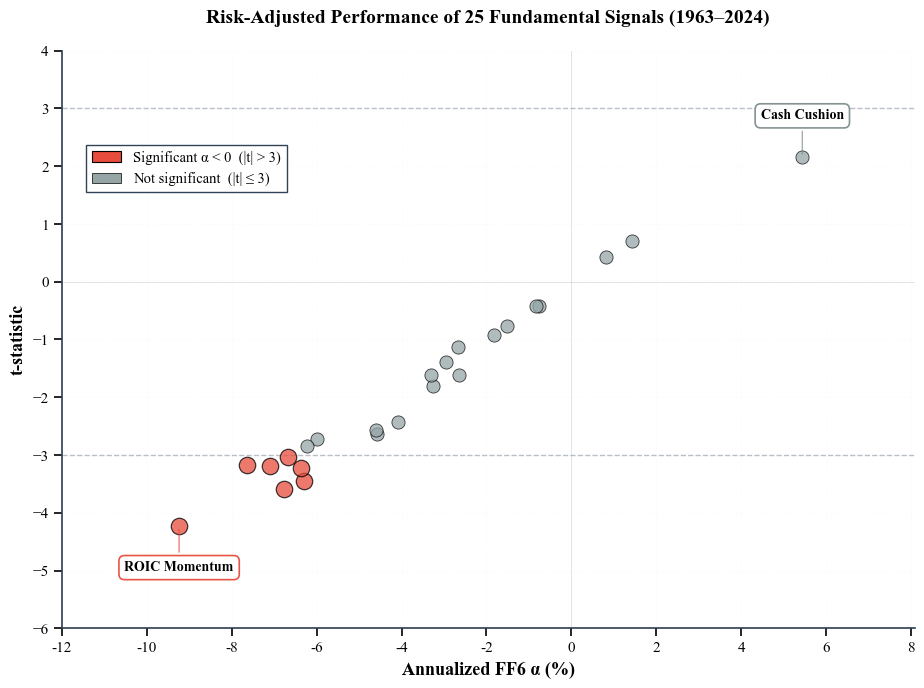

In [8]:
# ═══════════════════════════════════════════════════════════════════════
# RISK-ADJUSTED PERFORMANCE SCATTER PLOT 
# ═══════════════════════════════════════════════════════════════════════


rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
rcParams['text.usetex'] = False
rcParams['font.size'] = 12
rcParams['axes.labelsize'] = 13
rcParams['axes.titlesize'] = 14
rcParams['axes.titleweight'] = 'bold'
rcParams['xtick.labelsize'] = 11
rcParams['ytick.labelsize'] = 11
rcParams['legend.fontsize'] = 10.5


df_plot = df_vw[['Signal', 'Alpha Annual', 't-stat']].copy()
df_plot['signal_label'] = df_plot['Signal'].apply(lambda x: x.replace('_', ' ').title())

df_plot['significant'] = df_plot['t-stat'].abs() > 3.0
df_plot['positive_alpha'] = df_plot['Alpha Annual'] > 0

df_plot['color'] = '#95A5A6'  # Gris = Non significatif
df_plot.loc[df_plot['significant'] & df_plot['positive_alpha'], 'color'] = '#27AE60'   # Vert
df_plot.loc[df_plot['significant'] & ~df_plot['positive_alpha'], 'color'] = '#E74C3C'  # Rouge


fig, ax = plt.subplots(figsize=(11, 7.5), facecolor='white')
ax.set_facecolor('white')

# Scatter plot
for _, row in df_plot.iterrows():
    marker_size = 140 if row['significant'] else 90
    edge_width = 0.9 if row['significant'] else 0.6
    
    ax.scatter(
        row['Alpha Annual'], 
        row['t-stat'],
        c=row['color'],
        s=marker_size,
        alpha=0.75,
        edgecolors='black',
        linewidth=edge_width,
        zorder=3
    )


ax.axhline(y=3.0, color='#34495E', linestyle='--', linewidth=1.0, alpha=0.35, zorder=1)
ax.axhline(y=-3.0, color='#34495E', linestyle='--', linewidth=1.0, alpha=0.35, zorder=1)
ax.axhline(y=0, color='#7F8C8D', linestyle='-', linewidth=0.6, alpha=0.25, zorder=1)
ax.axvline(x=0, color='#7F8C8D', linestyle='-', linewidth=0.6, alpha=0.25, zorder=1)


cash_cushion_row = df_plot[df_plot['Signal'] == 'cash_cushion']
if not cash_cushion_row.empty:
    row = cash_cushion_row.iloc[0]
    y_offset = 0.6
    
    ax.annotate(
        'Cash Cushion',
        xy=(row['Alpha Annual'], row['t-stat']),
        xytext=(row['Alpha Annual'], row['t-stat'] + y_offset),
        fontsize=10,
        weight='semibold',
        ha='center',
        va='bottom',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#7F8C8D', linewidth=1.2, alpha=0.95),
        arrowprops=dict(arrowstyle='-', color='#7F8C8D', lw=1.0, alpha=0.7),
        zorder=5
    )

roic_momentum_row = df_plot[df_plot['Signal'] == 'roic_momentum']
if not roic_momentum_row.empty:
    row = roic_momentum_row.iloc[0]
    y_offset = -0.6
    
    ax.annotate(
        'ROIC Momentum',
        xy=(row['Alpha Annual'], row['t-stat']),
        xytext=(row['Alpha Annual'], row['t-stat'] + y_offset),
        fontsize=10,
        weight='semibold',
        ha='center',
        va='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#E74C3C', linewidth=1.2, alpha=0.95),
        arrowprops=dict(arrowstyle='-', color='#E74C3C', lw=1.0, alpha=0.7),
        zorder=5
    )

legend_elements = [
    mpatches.Patch(facecolor='#E74C3C', edgecolor='black', linewidth=0.8, 
                   label='Significant α < 0  (|t| > 3)'),
    mpatches.Patch(facecolor='#95A5A6', edgecolor='black', linewidth=0.5, 
                   label='Not significant  (|t| ≤ 3)'),
]

ax.legend(
    handles=legend_elements,
    loc='upper left',
    bbox_to_anchor=(0.02, 0.85),
    frameon=True,
    fancybox=False,
    shadow=False,
    framealpha=0.98,
    edgecolor='#2C3E50',
    facecolor='white',
    fontsize=10.5
)


ax.set_xlabel('Annualized FF6 α (%)', fontsize=13, weight='bold')
ax.set_ylabel('t-statistic', fontsize=13, weight='bold')
ax.set_title(
    'Risk-Adjusted Performance of 25 Fundamental Signals (1963–2024)',
    fontsize=14,
    weight='bold',
    pad=20
)


ax.grid(True, alpha=0.12, linestyle=':', linewidth=0.5, color='#BDC3C7', zorder=0)


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)
ax.spines['left'].set_color('#2C3E50')
ax.spines['bottom'].set_color('#2C3E50')




alpha_range = df_plot['Alpha Annual'].max() - df_plot['Alpha Annual'].min()
t_range = df_plot['t-stat'].max() - df_plot['t-stat'].min()

# X-AXIS : Limites en échelle mensuelle (inchangées)
ax.set_xlim(
    df_plot['Alpha Annual'].min() - 0.18 * alpha_range,
    df_plot['Alpha Annual'].max() + 0.18 * alpha_range
)


x_min = df_plot['Alpha Annual'].min() - 0.18 * alpha_range
x_max = df_plot['Alpha Annual'].max() + 0.18 * alpha_range

x_min_annual = x_min
x_max_annual = x_max

x_min_tick = int(np.floor(x_min_annual))
x_max_tick = int(np.ceil(x_max_annual))
xticks_annual = np.arange(x_min_tick, x_max_tick + 1, 2)

xticks_monthly = xticks_annual
ax.set_xticks(xticks_monthly)

xticklabels_annual = [f'{x:.0f}' for x in xticks_annual]
ax.set_xticklabels(xticklabels_annual)

y_min_auto = df_plot['t-stat'].min() - 0.18 * t_range
y_max_auto = df_plot['t-stat'].max() + 0.18 * t_range
y_max_final = max(y_max_auto, 3.5)

ax.set_ylim(y_min_auto, y_max_final)


y_min_tick = int(np.floor(y_min_auto))
y_max_tick = int(np.ceil(y_max_final))
yticks_final = np.arange(y_min_tick, y_max_tick + 1, 1)
ax.set_yticks(yticks_final)

ax.tick_params(axis='both', which='major', length=6, width=1.2, labelsize=11)

plt.show()